# K-means Clustering with Evaluation Metrics

This notebook demonstrates how to:
1. Generate synthetic data for clustering
2. Apply K-means clustering algorithm
3. Evaluate clustering performance using three metrics:
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index
4. Visualize the clustering results and find the optimal number of clusters

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate Synthetic Data

We'll create a synthetic dataset with a known number of clusters to demonstrate K-means clustering.

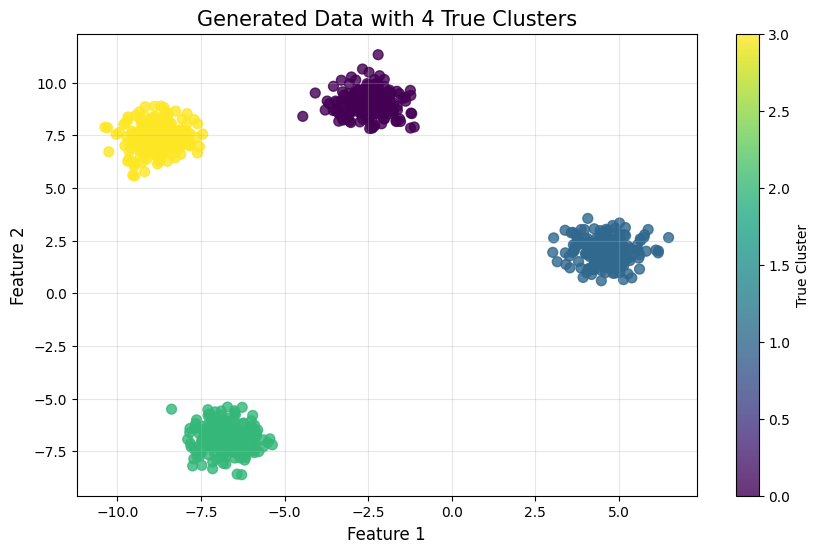

In [2]:
# Generate synthetic data with 4 true clusters
X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=0.60, random_state=42)

# Plot the generated data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8, s=50)
plt.title('Generated Data with 4 True Clusters', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='True Cluster')
plt.grid(alpha=0.3)
plt.show()

## 2. Apply K-means Clustering

Now, let's apply K-means clustering to our synthetic data. We'll try different numbers of clusters to see which one best fits the data.

In [3]:
# Function to perform K-means clustering and evaluate metrics
def perform_kmeans(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)
    
    # Calculate evaluation metrics
    silhouette = silhouette_score(X, clusters)
    calinski = calinski_harabasz_score(X, clusters)
    davies = davies_bouldin_score(X, clusters)
    
    return clusters, silhouette, calinski, davies, kmeans.inertia_

In [4]:
# Try different numbers of clusters
cluster_range = range(2, 11)
results = []

for n_clusters in cluster_range:
    clusters, silhouette, calinski, davies, inertia = perform_kmeans(X, n_clusters)
    results.append({
        'n_clusters': n_clusters,
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies,
        'inertia': inertia
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df

,n_clusters,silhouette,calinski_harabasz,davies_bouldin,inertia
0,2,0.614916,934.066368,0.485617,24128.976945
1,3,0.796813,3917.000548,0.315867,4836.126982
2,4,0.874185,24294.487290,0.176767,565.805505
3,5,0.746110,20144.045265,0.557287,511.711266
4,6,0.590680,17817.740325,0.848343,462.854838
5,7,0.463082,16824.382277,1.017497,408.692409
6,8,0.332789,16170.023600,1.171818,363.913008
7,9,0.337173,15540.251792,1.087560,331.178545
8,10,0.346710,15209.642733,1.006104,300.822819


## 3. Evaluate Clustering Performance

Let's understand what each evaluation metric means:

1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Range from -1 to 1, where higher values indicate better clustering.

2. **Calinski-Harabasz Index**: Ratio of between-cluster variance to within-cluster variance. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

4. **Inertia**: Sum of squared distances to the nearest centroid (used for the Elbow Method). Lower values indicate tighter clusters.

Now, let's visualize these metrics to determine the optimal number of clusters.

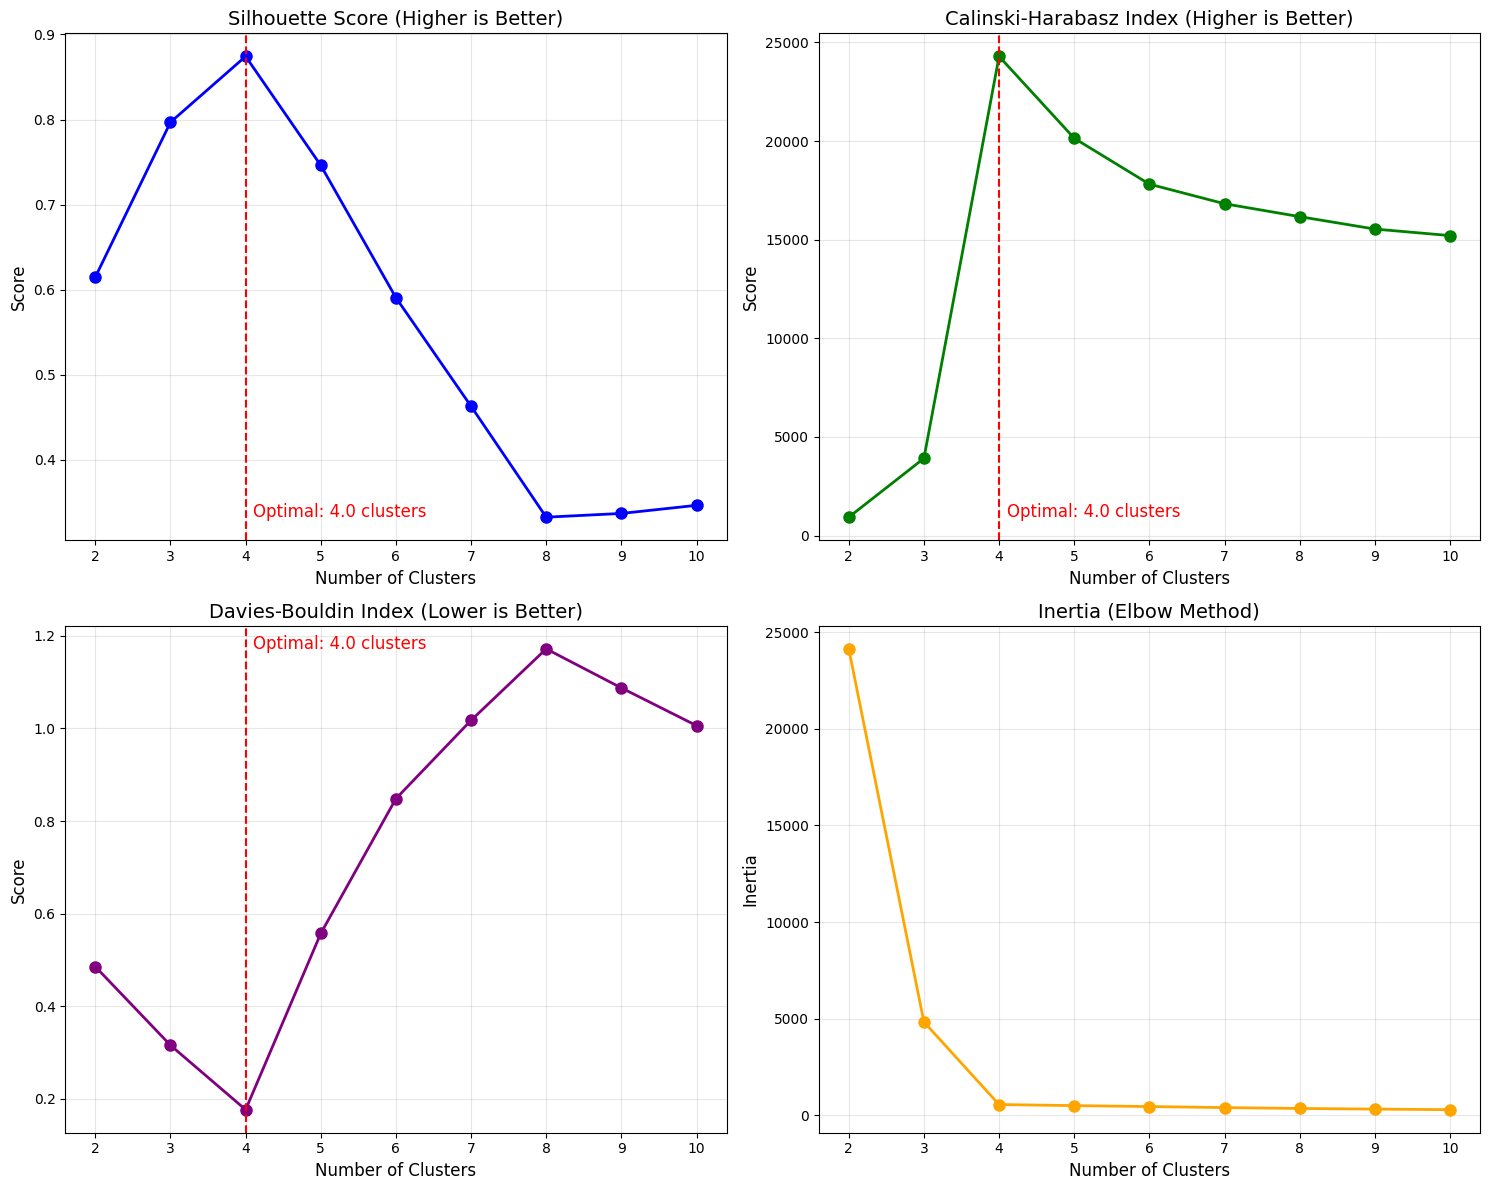

In [5]:
# Create a 2x2 grid for our evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Silhouette Score (higher is better)
axes[0, 0].plot(results_df['n_clusters'], results_df['silhouette'], 'o-', color='blue', linewidth=2, markersize=8)
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontsize=14)
axes[0, 0].set_xlabel('Number of Clusters', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].grid(alpha=0.3)
best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
axes[0, 0].axvline(x=best_silhouette['n_clusters'], color='red', linestyle='--')
axes[0, 0].text(best_silhouette['n_clusters']+0.1, results_df['silhouette'].min(), 
               f'Optimal: {best_silhouette["n_clusters"]} clusters', 
               color='red', fontsize=12)

# Calinski-Harabasz Index (higher is better)
axes[0, 1].plot(results_df['n_clusters'], results_df['calinski_harabasz'], 'o-', color='green', linewidth=2, markersize=8)
axes[0, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=14)
axes[0, 1].set_xlabel('Number of Clusters', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].grid(alpha=0.3)
best_calinski = results_df.loc[results_df['calinski_harabasz'].idxmax()]
axes[0, 1].axvline(x=best_calinski['n_clusters'], color='red', linestyle='--')
axes[0, 1].text(best_calinski['n_clusters']+0.1, results_df['calinski_harabasz'].min(), 
               f'Optimal: {best_calinski["n_clusters"]} clusters', 
               color='red', fontsize=12)

# Davies-Bouldin Index (lower is better)
axes[1, 0].plot(results_df['n_clusters'], results_df['davies_bouldin'], 'o-', color='purple', linewidth=2, markersize=8)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14)
axes[1, 0].set_xlabel('Number of Clusters', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].grid(alpha=0.3)
best_davies = results_df.loc[results_df['davies_bouldin'].idxmin()]
axes[1, 0].axvline(x=best_davies['n_clusters'], color='red', linestyle='--')
axes[1, 0].text(best_davies['n_clusters']+0.1, results_df['davies_bouldin'].max(), 
               f'Optimal: {best_davies["n_clusters"]} clusters', 
               color='red', fontsize=12)

# Inertia (Elbow Method - lower is better)
axes[1, 1].plot(results_df['n_clusters'], results_df['inertia'], 'o-', color='orange', linewidth=2, markersize=8)
axes[1, 1].set_title('Inertia (Elbow Method)', fontsize=14)
axes[1, 1].set_xlabel('Number of Clusters', fontsize=12)
axes[1, 1].set_ylabel('Inertia', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Visualize the Clustering Results

Now, let's visualize the clustering results for the optimal number of clusters. According to our evaluation metrics, the optimal number appears to be 4 clusters.

In [6]:
# Print the optimal number of clusters according to each metric
print(f"Silhouette Score suggests {best_silhouette['n_clusters']} clusters")
print(f"Calinski-Harabasz Index suggests {best_calinski['n_clusters']} clusters")
print(f"Davies-Bouldin Index suggests {best_davies['n_clusters']} clusters")

# Determine the most frequently suggested optimal number of clusters
optimal_suggestions = [best_silhouette['n_clusters'], best_calinski['n_clusters'], best_davies['n_clusters']]
from collections import Counter
counter = Counter(optimal_suggestions)
optimal_k = int(counter.most_common(1)[0][0])

print(f"\nBased on majority voting, the optimal number of clusters is: {optimal_k}")

Silhouette Score suggests 4.0 clusters
Calinski-Harabasz Index suggests 4.0 clusters
Davies-Bouldin Index suggests 4.0 clusters

Based on majority voting, the optimal number of clusters is: 4


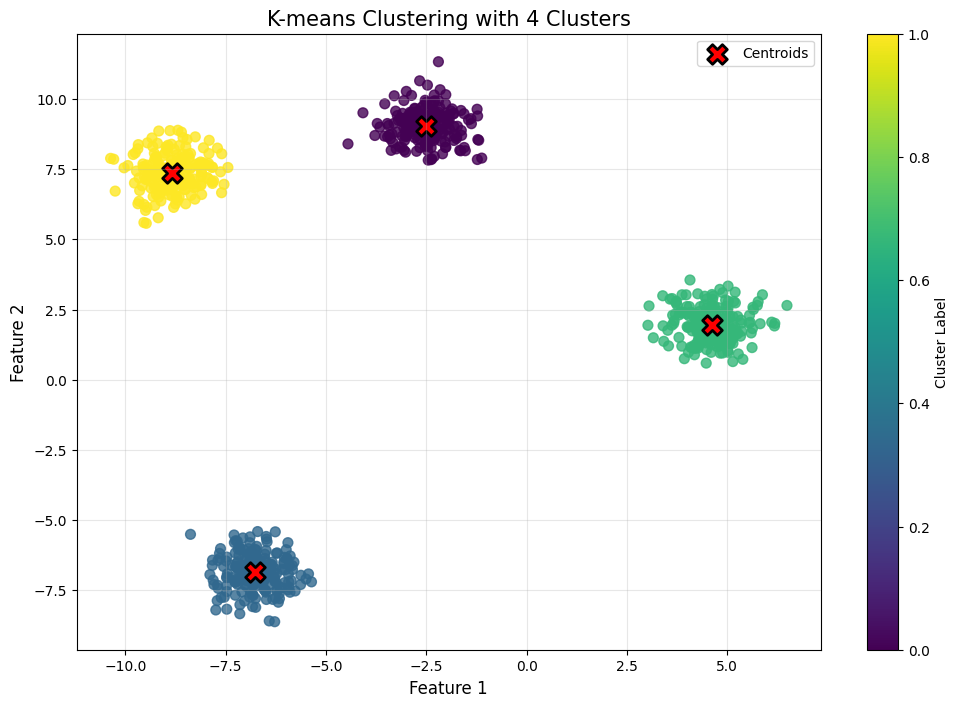

In [7]:
# Perform K-means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Plot the clusters
plt.figure(figsize=(12, 8))

# Plot data points with their assigned clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.8, s=50)

# Plot the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', 
            edgecolor='black', linewidth=2, label='Centroids')

plt.title(f'K-means Clustering with {optimal_k} Clusters', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.colorbar(label='Cluster Label')
plt.show()

## 5. Create a More Complex Dataset

Let's create a more complex dataset to test our clustering approach.

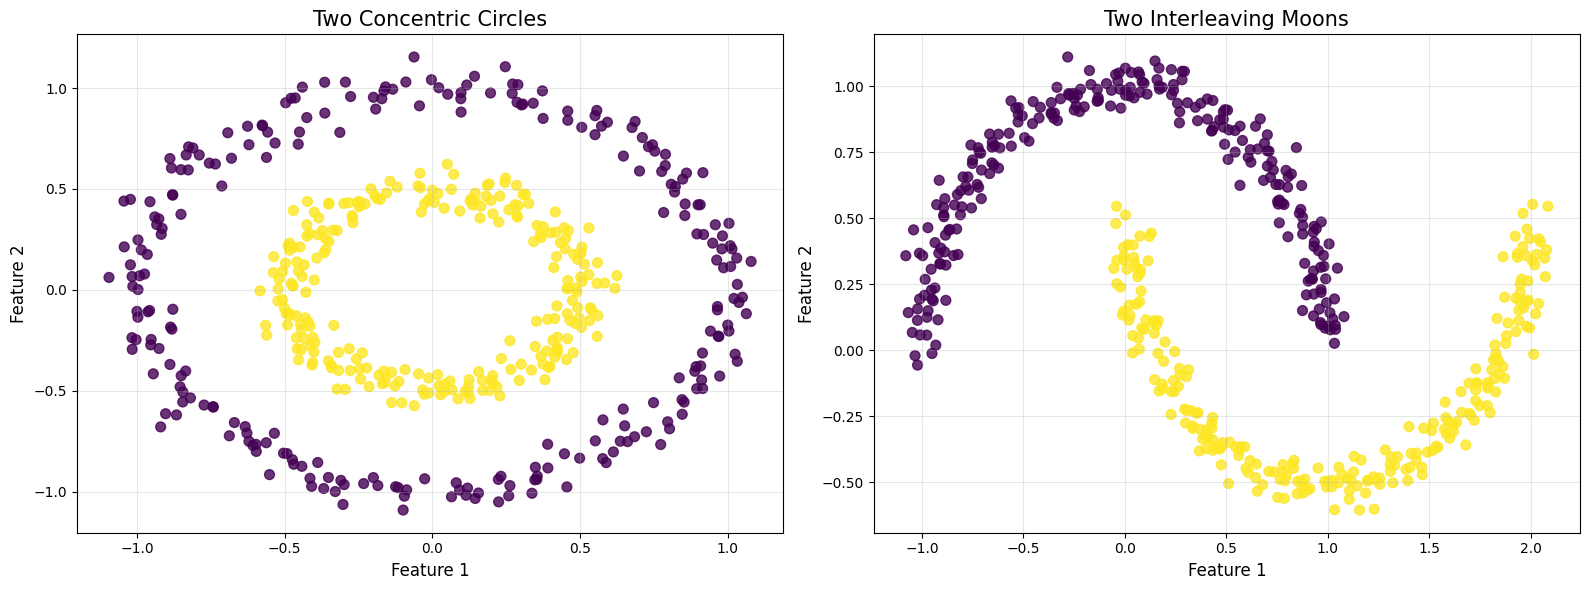

In [8]:
# Generate a more complex dataset
from sklearn.datasets import make_moons, make_circles

# Generate two interleaving half circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# Generate two interleaving moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)

# Plot the complex datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.8, s=50)
axes[0].set_title('Two Concentric Circles', fontsize=15)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.8, s=50)
axes[1].set_title('Two Interleaving Moons', fontsize=15)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate K-means on Complex Datasets

Let's apply K-means to these more complex datasets and evaluate the results.

In [9]:
# Function to evaluate K-means on a dataset
def evaluate_kmeans(X, true_labels, n_clusters=2):
    # Apply K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    predicted_labels = kmeans.fit_predict(X)
    
    # Calculate evaluation metrics
    silhouette = silhouette_score(X, predicted_labels)
    calinski = calinski_harabasz_score(X, predicted_labels)
    davies = davies_bouldin_score(X, predicted_labels)
    
    # Plot results
    plt.figure(figsize=(16, 6))
    
    # True labels
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', alpha=0.8, s=50)
    plt.title('True Labels', fontsize=15)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(alpha=0.3)
    
    # K-means prediction
    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=predicted_labels, cmap='viridis', alpha=0.8, s=50)
    centroids = kmeans.cluster_centers_
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', 
                edgecolor='black', linewidth=2, label='Centroids')
    plt.title(f'K-means Clustering (k={n_clusters})', fontsize=15)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print(f"Silhouette Score: {silhouette:.4f} (higher is better)")
    print(f"Calinski-Harabasz Index: {calinski:.4f} (higher is better)")
    print(f"Davies-Bouldin Index: {davies:.4f} (lower is better)")

Evaluation for Circles Dataset:


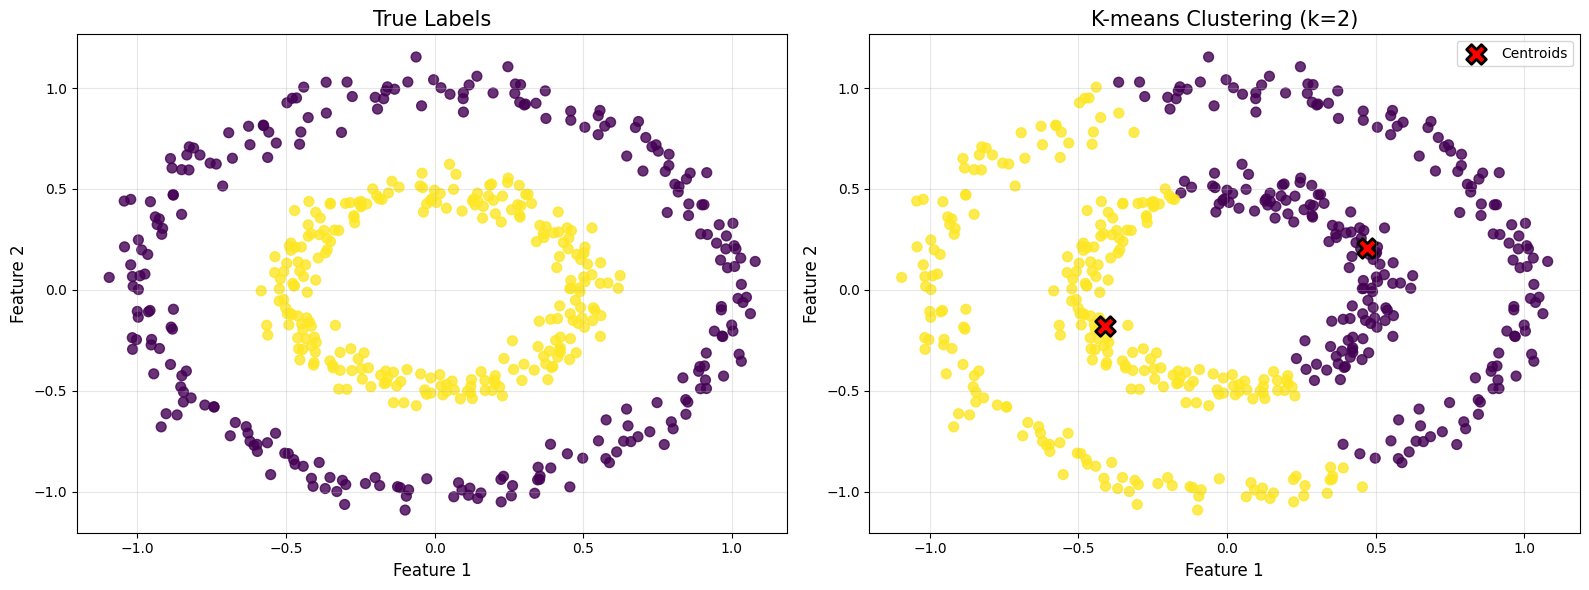

Silhouette Score: 0.3556 (higher is better)
Calinski-Harabasz Index: 290.5728 (higher is better)
Davies-Bouldin Index: 1.1714 (lower is better)


In [10]:
print("Evaluation for Circles Dataset:")
evaluate_kmeans(X_circles, y_circles)

Evaluation for Moons Dataset:


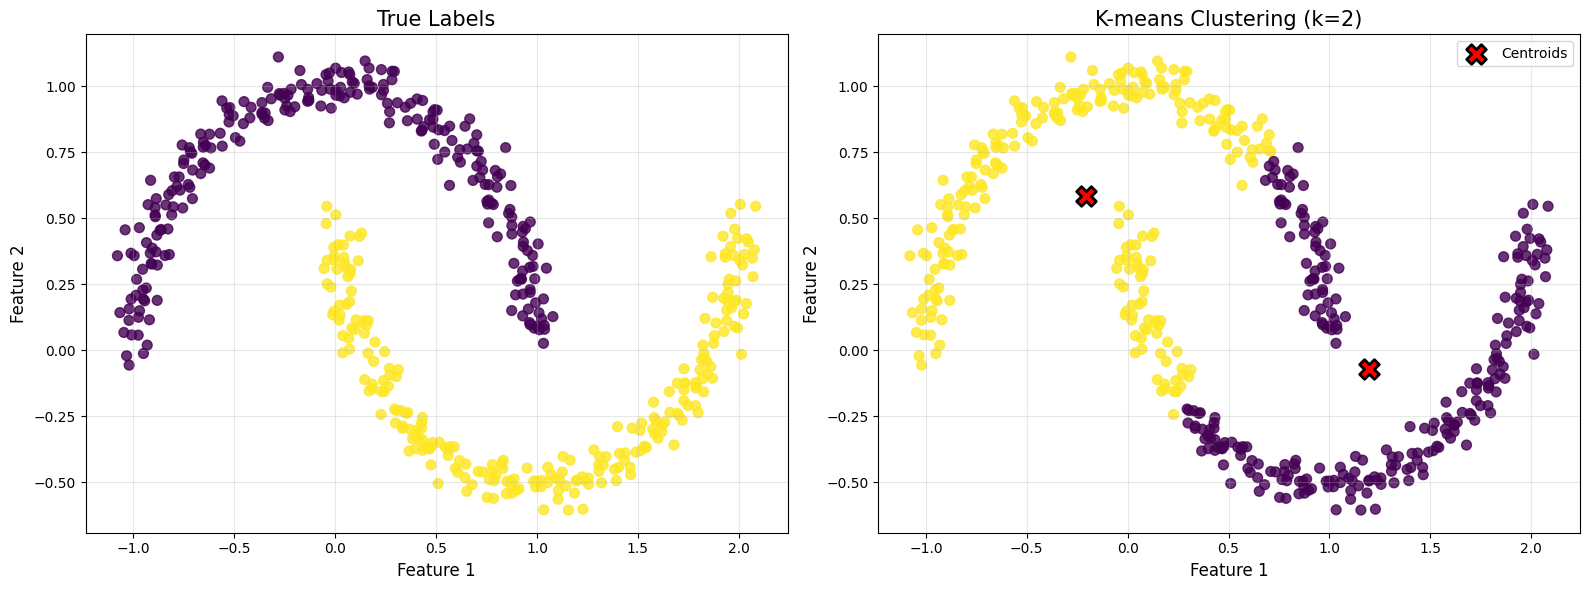

Silhouette Score: 0.4888 (higher is better)
Calinski-Harabasz Index: 736.3984 (higher is better)
Davies-Bouldin Index: 0.7826 (lower is better)


In [11]:
print("Evaluation for Moons Dataset:")
evaluate_kmeans(X_moons, y_moons)

## 7. Conclusion and Key Takeaways

In this notebook, we've demonstrated the K-means clustering algorithm and evaluated its performance using three different metrics:

1. **Silhouette Score**: Measures the quality of clusters by looking at how similar an object is to its own cluster compared to other clusters. Range: [-1, 1], higher is better.

2. **Calinski-Harabasz Index**: Measures the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

**Key takeaways:**

- K-means works well for spherical, similarly sized clusters
- It struggles with non-spherical shapes (like circles or moons)
- Evaluation metrics can help determine the optimal number of clusters
- For complex shapes, alternative clustering algorithms like Spectral Clustering may perform better
- No single evaluation metric is perfect; using multiple metrics provides a more robust assessment

When applying clustering in real-world scenarios, it's important to:
1. Explore your data first
2. Try different clustering algorithms
3. Use multiple evaluation metrics
4. Consider domain knowledge when interpreting results